In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = {
    "Area":[1000,1200,1500,1800,2000,2200,2500,3000],
    "Bedrooms":[2,2,3,3,4,4,4,5],
    "Bathrooms":[1,2,2,2,3,3,3,4],
    "Age":[10,8,7,6,5,4,3,2],
    "Parking":[1,1,2,2,2,3,3,4],
    "Price":[35,40,50,60,70,75,85,100]
}

df = pd.DataFrame(data)

In [3]:
df.head()
df.shape
df.columns
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Area       8 non-null      int64
 1   Bedrooms   8 non-null      int64
 2   Bathrooms  8 non-null      int64
 3   Age        8 non-null      int64
 4   Parking    8 non-null      int64
 5   Price      8 non-null      int64
dtypes: int64(6)
memory usage: 516.0 bytes


np.int64(0)

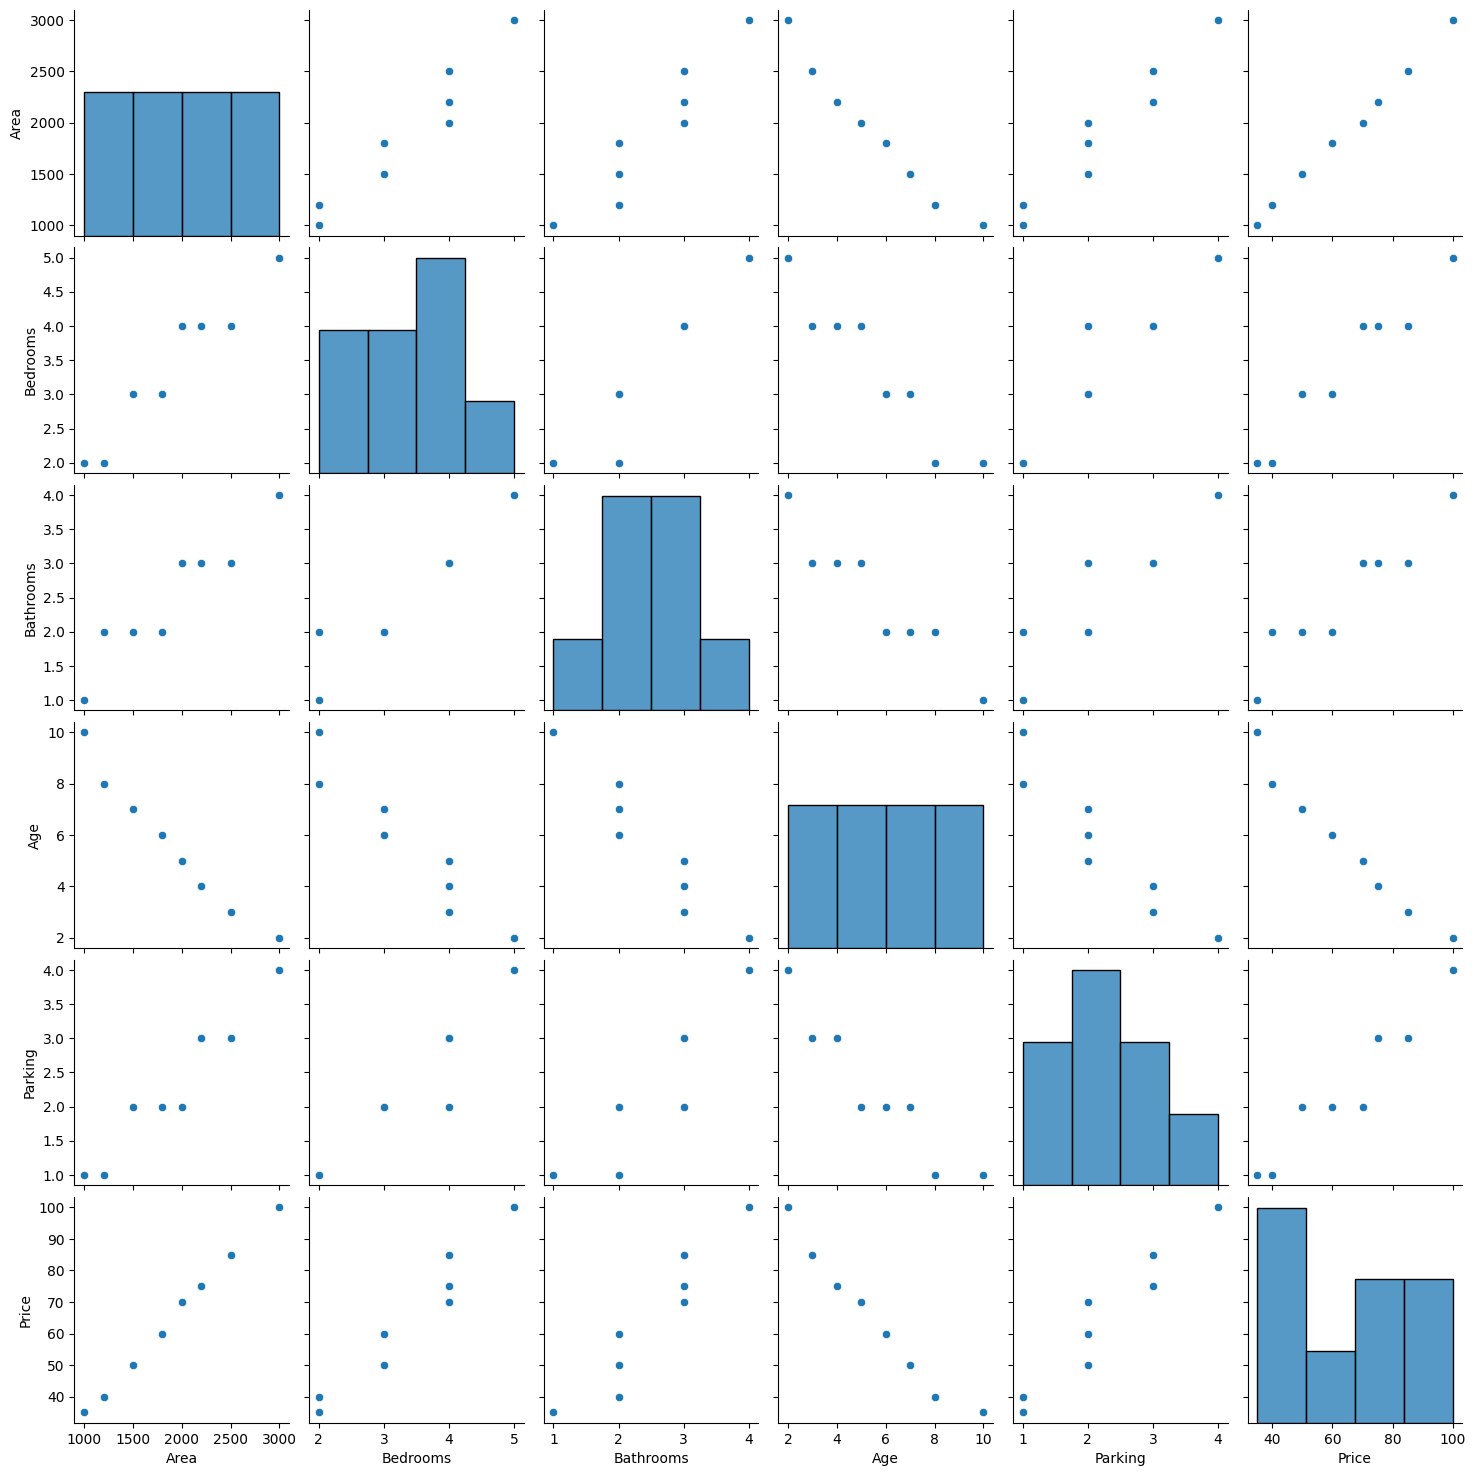

In [5]:
sns.pairplot(df)
plt.show()

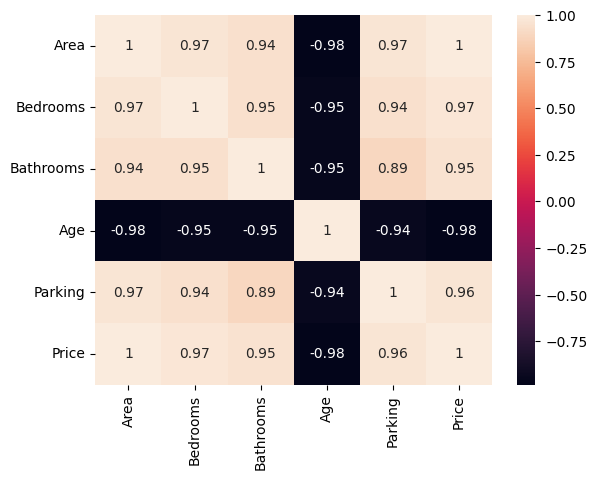

In [6]:
sns.heatmap(df.corr(),annot=True)
plt.show()

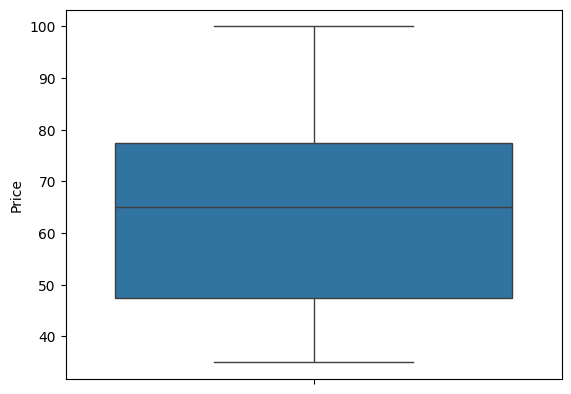

In [7]:
sns.boxplot(df["Price"])
plt.show()

In [8]:
X = df.drop("Price",axis=1)

y = df["Price"]

In [9]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

In [10]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()

model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 0.04, 0.82, 0.82, 0.33,-4.24]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Area','Bedrooms','Bathrooms','Age','Parking']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-4.946
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [12]:
model.score(X_test,y_test)*100

98.48337255507202

In [13]:
prediction=model.predict(X_test)

In [14]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae=mean_absolute_error(y_test,prediction)

mse=mean_squared_error(y_test,prediction)

rmse=np.sqrt(mse)

r2=r2_score(y_test,prediction)

In [15]:
coef=pd.DataFrame({
"Feature":X.columns,
"Coefficient":model.coef_
})

coef

,Feature,Coefficient
0,Area,0.038043
1,Bedrooms,0.815217
2,Bathrooms,0.815217
3,Age,0.326087
4,Parking,-4.239130


In [16]:
comparison=pd.DataFrame({
"Actual":y_test,
"Predicted":prediction
}).reset_index(drop=True)

comparison.head(10)

,Actual,Predicted
0,40,42.336957
1,75,73.043478


In [17]:
new_house=pd.DataFrame({

"Area":[2300],
"Bedrooms":[4],
"Bathrooms":[3],
"Age":[4],
"Parking":[2]

})

model.predict(new_house)

array([81.08695652])

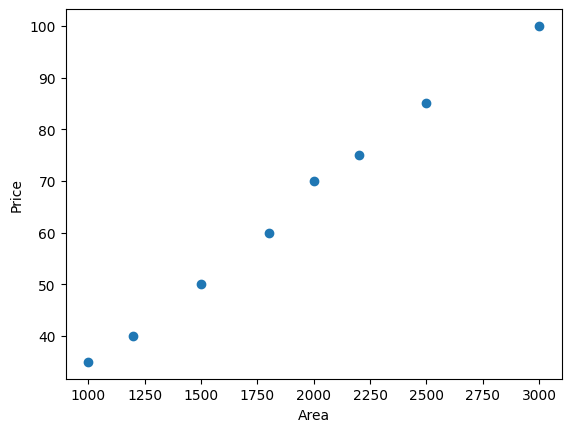

In [18]:
plt.scatter(df["Area"],df["Price"])
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

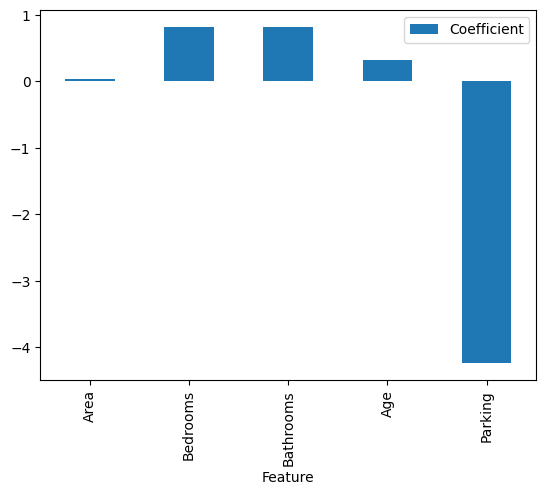

In [19]:
coef.plot(
x="Feature",
y="Coefficient",
kind="bar"
)
plt.show()

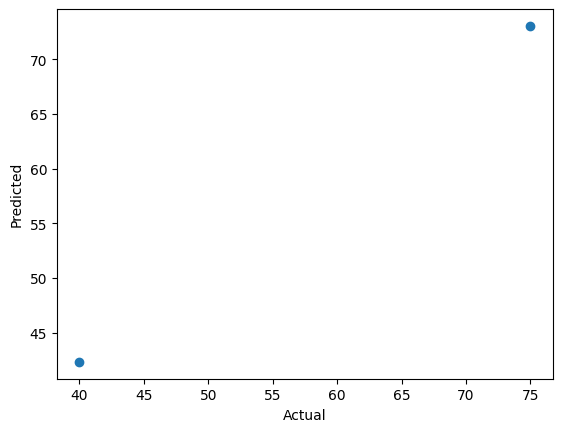

In [20]:
plt.scatter(y_test,prediction)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.show()